# Lab 3 — Oscillator Simulation
**Name:** Alex Bebb<br>
**Date:** September 13, 2026

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Part A — The Simple Harmonic Oscillator

I model a mass attached to a spring with no damping or external driving
force. Position is measured from equilibrium, so the restoring force is

$$F=-kx.$$

The acceleration is therefore

$$a=-\frac{k}{m}x.$$

I will compare standard Euler and Euler-Cromer with the exact solution,
then examine how each method affects total mechanical energy.

### Parameters and exact solution

I set the mass to 1.0 kg and the spring constant to 1.0 N/m. The mass
starts 1.0 m from equilibrium and is released from rest.

I calculate the natural angular frequency and period using

$$\omega_0=\sqrt{\frac{k}{m}}, \qquad T=\frac{2\pi}{\omega_0}.$$

For these initial conditions, the exact position and velocity are

$$x(t)=x_0\cos(\omega_0t),$$

$$v(t)=-x_0\omega_0\sin(\omega_0t).$$

The functions below evaluate these expressions so I can compare them
with the numerical results. I also print the frequency, period, and
initial energy to check the setup.

In [2]:
# Physical parameters
k = 1.0   # Spring constant (N/m)
m = 1.0   # Mass (kg)

# Initial conditions
x0 = 1.0  # Initial displacement (m)
v0 = 0.0  # Initial velocity (m/s)

# Natural angular frequency and period
omega0 = np.sqrt(k / m)    # rad/s
T = 2 * np.pi / omega0     # s

# Exact solution for release from rest at x0
def exact_x(t):
    return x0 * np.cos(omega0 * t)

def exact_v(t):
    return -x0 * omega0 * np.sin(omega0 * t)

# Report characteristic quantities
initial_energy = 0.5 * k * x0**2 + 0.5 * m * v0**2

print(f"Natural angular frequency: {omega0:.4f} rad/s")
print(f"Period: {T:.4f} s")
print(f"Initial mechanical energy: {initial_energy:.4f} J")

Natural angular frequency: 1.0000 rad/s
Period: 6.2832 s
Initial mechanical energy: 0.5000 J


### Building the oscillator simulator

This function simulates the spring–mass system using either standard
Euler or Euler-Cromer. It starts from the initial conditions defined
above and advances the motion through small time steps.

At each step, the acceleration is calculated from the current position:

$$a=-\frac{k}{m}x.$$

Standard Euler updates position using the old velocity. Euler-Cromer
updates velocity first and uses that new velocity to update position.

After each step, the function stores time, position, velocity, and total
mechanical energy:

$$E=\frac12kx^2+\frac12mv^2.$$

It returns these histories as NumPy arrays for plotting and analysis.
Since the system has no damping or driving force, the physical energy
should remain constant. Changes in the calculated energy therefore
provide a check on numerical error.

In [3]:
def simulate_sho(method, dt, n_periods=10):
    """Simulate the simple harmonic oscillator.

    Parameters:
        method    : 'euler' or 'euler-cromer'
        dt        : time step (s)
        n_periods : number of natural periods to simulate

    Uses k, m, x0, v0, and T defined above.
    Returns NumPy arrays of time, position, velocity, and energy.
    """

    # Check that the method name is recognized
    if method not in ('euler', 'euler-cromer'):
        raise ValueError("method must be 'euler' or 'euler-cromer'")

    # Set the duration and initial state
    t_max = n_periods * T
    t = 0.0
    x = x0
    v = v0

    # Store the initial state and energy
    energy = 0.5 * k * x**2 + 0.5 * m * v**2

    t_history = [t]
    x_history = [x]
    v_history = [v]
    E_history = [energy]

    while t < t_max:
        # Acceleration from the CURRENT position
        a = -(k / m) * x

        if method == 'euler':
            # Calculate both updates from the old state
            x_new = x + v * dt
            v_new = v + a * dt

            # Replace the old state with the new state
            x = x_new
            v = v_new

        elif method == 'euler-cromer':
            # Update velocity first
            v = v + a * dt

            # Position uses the updated velocity
            x = x + v * dt

        # Advance time and calculate the updated energy
        t = t + dt
        energy = 0.5 * k * x**2 + 0.5 * m * v**2

        # Store the updated results
        t_history.append(t)
        x_history.append(x)
        v_history.append(v)
        E_history.append(energy)

    return (
        np.array(t_history),
        np.array(x_history),
        np.array(v_history),
        np.array(E_history)
    )

### Running both methods

I run both methods with identical initial conditions and a time step
of 0.05 s for ten natural periods. Keeping these settings the same lets
me compare the effects of the integration methods.

Each call starts a new simulation, and I store the results separately.
I print the requested duration, final stored time, and initial and final
energies as an initial check before plotting.

The loop uses fixed time steps, so the final stored time can extend
slightly beyond the requested duration. The final energy alone does
not show how energy behaved throughout the run; the next plots will
show that history.

In [4]:
# Assignment settings
dt_sho = 0.05
n_periods_sho = 10

# Run standard Euler
t_e, x_e, v_e, E_e = simulate_sho(
    method='euler',
    dt=dt_sho,
    n_periods=n_periods_sho
)

# Run Euler-Cromer
t_ec, x_ec, v_ec, E_ec = simulate_sho(
    method='euler-cromer',
    dt=dt_sho,
    n_periods=n_periods_sho
)

# Check the simulation duration and final energies
print(f"Requested duration: {n_periods_sho * T:.4f} s")
print(f"Last stored time: {t_e[-1]:.4f} s")
print(f"Initial energy: {E_e[0]:.4f} J")
print(f"Euler final energy: {E_e[-1]:.4f} J")
print(f"Euler-Cromer final energy: {E_ec[-1]:.4f} J")

Requested duration: 62.8319 s
Last stored time: 62.8500 s
Initial energy: 0.5000 J
Euler final energy: 11.5355 J
Euler-Cromer final energy: 0.4994 J


### Comparing position with the exact solution

I plot the position calculated by both methods alongside the exact
solution for a mass released from rest. All three curves use the same
physical parameters and initial conditions.

This comparison shows whether the numerical methods reproduce the
amplitude and timing of the motion over ten periods.

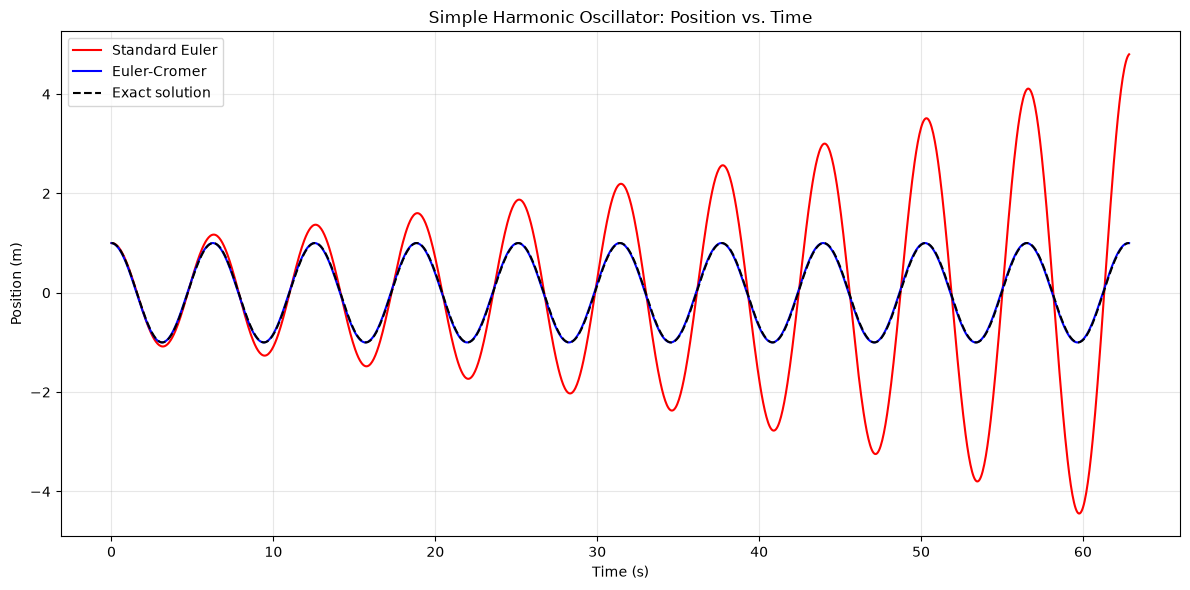

In [5]:
# Evaluate the exact solution at the stored simulation times
x_exact = exact_x(t_e)

plt.figure(figsize=(12, 6))

plt.plot(
    t_e, x_e,
    color='red',
    label='Standard Euler',
    linewidth=1.5
)

plt.plot(
    t_ec, x_ec,
    color='blue',
    label='Euler-Cromer',
    linewidth=1.5
)

plt.plot(
    t_e, x_exact,
    color='black',
    linestyle='--',
    label='Exact solution',
    linewidth=1.5
)

plt.xlabel('Time (s)')
plt.ylabel('Position (m)')
plt.title('Simple Harmonic Oscillator: Position vs. Time')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Comparing total mechanical energy

I plot the total mechanical energy from both simulations and include a
horizontal line at the initial energy. With no damping or driving,
the exact total energy remains constant.

The complete energy histories show whether numerical error grows over
time or remains bounded. This provides information that a comparison
of only the initial and final energies could miss.

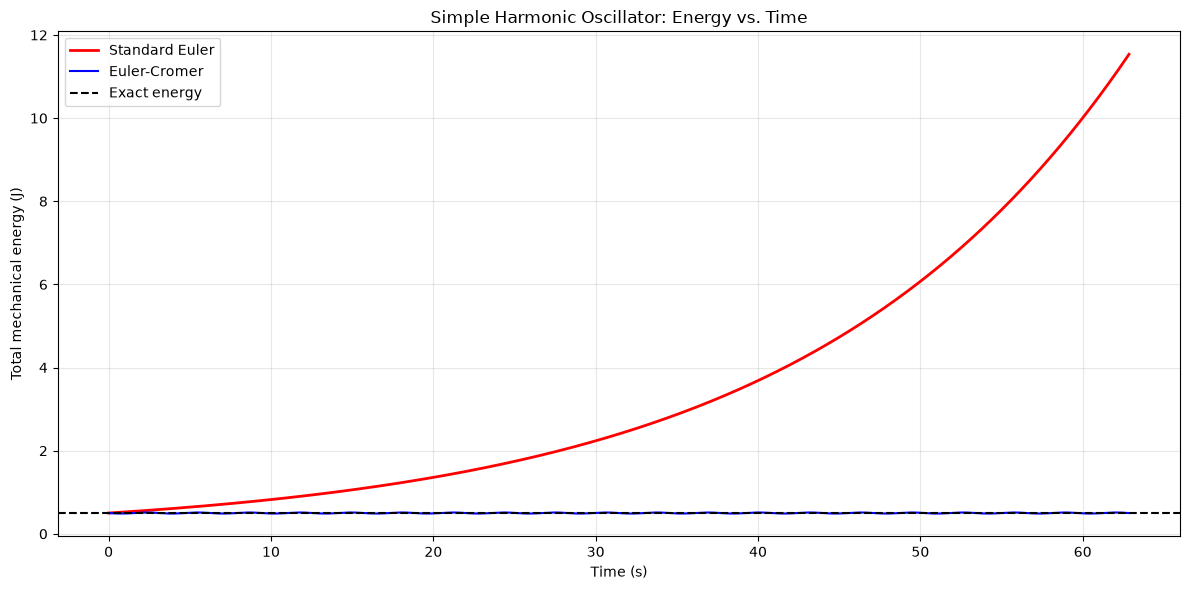

In [6]:
plt.figure(figsize=(12, 6))

plt.plot(
    t_e, E_e,
    color='red',
    label='Standard Euler',
    linewidth=2
)

plt.plot(
    t_ec, E_ec,
    color='blue',
    label='Euler-Cromer',
    linewidth=1.5
)

plt.axhline(
    y=initial_energy,
    color='black',
    linestyle='--',
    label='Exact energy',
    linewidth=1.5
)

plt.xlabel('Time (s)')
plt.ylabel('Total mechanical energy (J)')
plt.title('Simple Harmonic Oscillator: Energy vs. Time')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Interpretation

Over ten periods, the standard Euler solution’s amplitude grows, and its energy increases from 0.5000 J to 11.5355 J, even though the physical system has no source of additional energy. Euler-Cromer stays close to the exact position curve, and its energy has small, bounded oscillations rather than steadily increasing. Its final energy of 0.4994 J is close to the initial value, but this does not mean it conserves energy exactly throughout the simulation.


## Part B — Phase Space and Damped Oscillations

### B.1 — Comparing phase-space portraits

I plot velocity against position for the two simulations from Part A.
Each point represents the position and velocity at the same instant;
time progresses along the curve instead of appearing on an axis.

For the exact undamped oscillator, the motion traces an ellipse in
phase space. Comparing the numerical curves helps show how each
method's errors affect the motion.

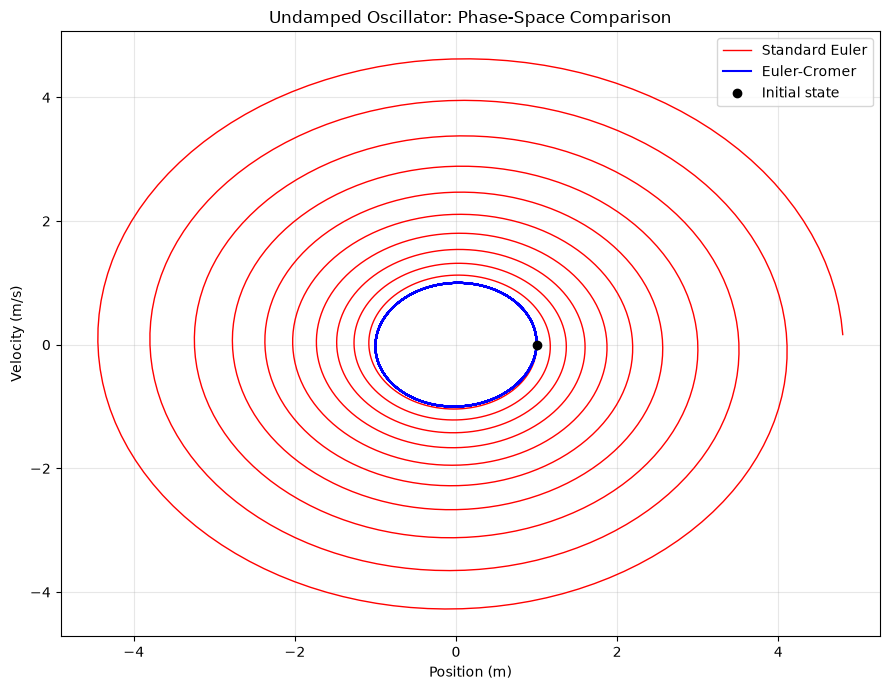

In [7]:
plt.figure(figsize=(9, 7))

# Phase-space trajectory for standard Euler
plt.plot(
    x_e, v_e,
    color='red',
    label='Standard Euler',
    linewidth=1
)

# Phase-space trajectory for Euler-Cromer
plt.plot(
    x_ec, v_ec,
    color='blue',
    label='Euler-Cromer',
    linewidth=1.5
)

# Both simulations start at the same position and velocity
plt.plot(
    x0, v0,
    marker='o',
    color='black',
    linestyle='None',
    label='Initial state',
    markersize=6
)

plt.xlabel('Position (m)')
plt.ylabel('Velocity (m/s)')
plt.title('Undamped Oscillator: Phase-Space Comparison')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Interpretation

The standard Euler trajectory spirals outward, consistent with the
increasing amplitude and energy seen in Part A. Euler-Cromer stays
near an ellipse without a growing outward spiral, consistent with
its bounded energy error.

### B.2 — Adding damping

I add a damping force proportional to velocity and opposite to the
direction of motion. The equation of motion becomes

$$a=-\frac{k}{m}x-\frac{b}{m}v.$$

The function uses Euler-Cromer and stores time, position, velocity,
and total mechanical energy. Unlike the undamped case, mechanical
energy can now decrease physically because of damping.

I classify the motion using the damping ratio

$$\zeta=\frac{b}{2\sqrt{km}}.$$

The three cases are underdamped, critically damped, and overdamped.

In [8]:
def simulate_damped_sho(b, dt=0.01, t_max=30.0):
    """Simulate a linearly damped spring using Euler-Cromer.

    Parameters:
        b     : damping coefficient (kg/s)
        dt    : time step (s)
        t_max : requested simulation duration (s)

    Uses k, m, x0, and v0 defined above.
    Returns arrays of time, position, velocity, and energy.
    """

    # Initial state
    t = 0.0
    x = x0
    v = v0

    # Initial mechanical energy (J)
    energy = 0.5 * k * x**2 + 0.5 * m * v**2

    # Storage
    t_history = [t]
    x_history = [x]
    v_history = [v]
    E_history = [energy]

    while t < t_max:
        # Spring and damping acceleration from the current state
        a = -(k / m) * x - (b / m) * v

        # Euler-Cromer: velocity first, then position
        v = v + a * dt
        x = x + v * dt
        t = t + dt

        # Mechanical energy at the updated state
        energy = 0.5 * k * x**2 + 0.5 * m * v**2

        t_history.append(t)
        x_history.append(x)
        v_history.append(v)
        E_history.append(energy)

    return (
        np.array(t_history),
        np.array(x_history),
        np.array(v_history),
        np.array(E_history)
    )

### Comparing damping strengths

I keep the mass, spring constant, and initial conditions fixed and
change only the damping coefficient.

With k = 1.0 N/m and m = 1.0 kg, the coefficients b = 0.2, 2.0,
and 4.0 kg/s give damping ratios of 0.1, 1.0, and 2.0.

I run each case for 30 seconds with a time step of 0.01 seconds.
The underdamped case should oscillate with decreasing amplitude.
The critical and overdamped cases should approach equilibrium
without oscillating for these initial conditions.

In [9]:
# Shared numerical settings
dt_damped = 0.01
duration_damped = 30.0

# Damping coefficients (kg/s)
b_under = 0.2
b_critical = 2.0
b_over = 4.0

# Underdamped
t_under, x_under, v_under, E_under = simulate_damped_sho(
    b=b_under,
    dt=dt_damped,
    t_max=duration_damped
)

# Critically damped
t_critical, x_critical, v_critical, E_critical = simulate_damped_sho(
    b=b_critical,
    dt=dt_damped,
    t_max=duration_damped
)

# Overdamped
t_over, x_over, v_over, E_over = simulate_damped_sho(
    b=b_over,
    dt=dt_damped,
    t_max=duration_damped
)

# Calculate and print the damping ratios
zeta_under = b_under / (2 * np.sqrt(k * m))
zeta_critical = b_critical / (2 * np.sqrt(k * m))
zeta_over = b_over / (2 * np.sqrt(k * m))

print(f"Underdamped damping ratio: {zeta_under:.2f}")
print(f"Critical damping ratio: {zeta_critical:.2f}")
print(f"Overdamped damping ratio: {zeta_over:.2f}")

Underdamped damping ratio: 0.10
Critical damping ratio: 1.00
Overdamped damping ratio: 2.00


### Position versus time and the underdamped envelope

I plot position versus time for all three damping regimes.

For the underdamped case, I also plot the theoretical upper and lower
decay envelopes. With initial displacement x0 and zero initial velocity,
the exact solution is

$$x(t)=e^{-\beta t}
\left[
x_0\cos(\omega_1t)
+\frac{\beta x_0}{\omega_1}\sin(\omega_1t)
\right],$$

where

$$\beta=\frac{b}{2m},
\qquad
\omega_1=\sqrt{\omega_0^2-\beta^2}.$$

Writing this solution as a phase-shifted cosine gives the envelope
amplitude

$$A=\sqrt{x_0^2+\left(\frac{\beta x_0}{\omega_1}\right)^2}.$$

The upper and lower envelopes are therefore
$+Ae^{-\beta t}$ and $-Ae^{-\beta t}$.

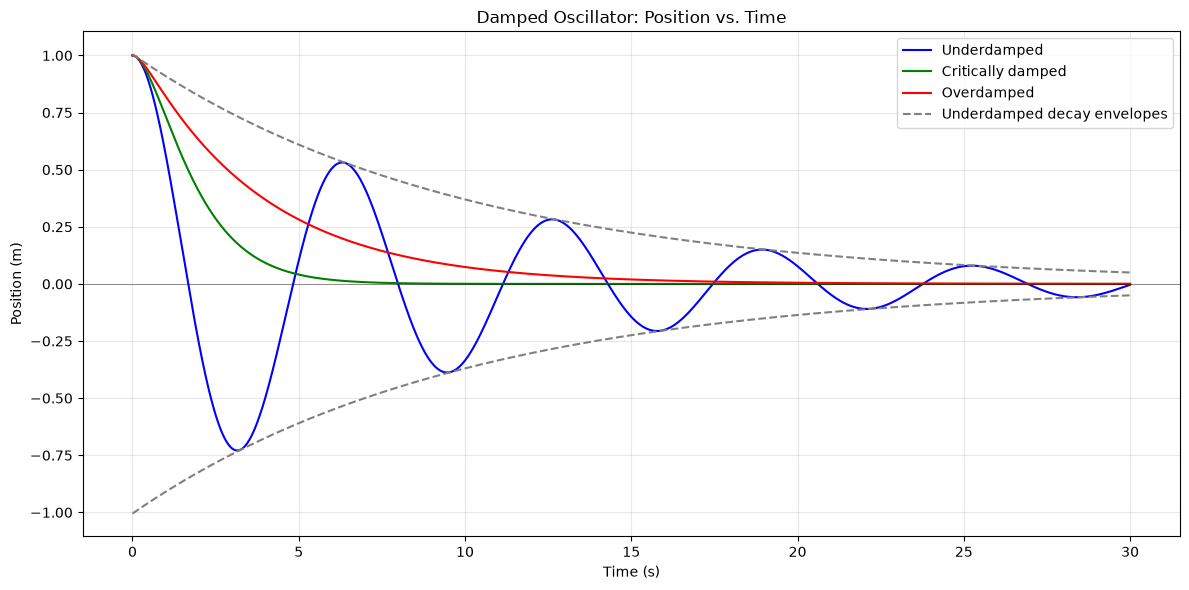

In [10]:
# Parameters for the underdamped theoretical envelope
beta_under = b_under / (2 * m)
omega1_under = np.sqrt(omega0**2 - beta_under**2)

# Envelope amplitude for release from rest at x0
A_envelope = np.sqrt(
    x0**2 + (beta_under * x0 / omega1_under)**2
)

envelope = A_envelope * np.exp(-beta_under * t_under)

# Plot the three numerical solutions
plt.figure(figsize=(12, 6))

plt.plot(
    t_under, x_under,
    color='blue',
    label='Underdamped',
    linewidth=1.5
)

plt.plot(
    t_critical, x_critical,
    color='green',
    label='Critically damped',
    linewidth=1.5
)

plt.plot(
    t_over, x_over,
    color='red',
    label='Overdamped',
    linewidth=1.5
)

# Upper and lower theoretical envelopes
plt.plot(
    t_under, envelope,
    color='gray',
    linestyle='--',
    label='Underdamped decay envelopes'
)

plt.plot(
    t_under, -envelope,
    color='gray',
    linestyle='--'
)

plt.axhline(y=0.0, color='black', linewidth=0.7, alpha=0.4)

plt.xlabel('Time (s)')
plt.ylabel('Position (m)')
plt.title('Damped Oscillator: Position vs. Time')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Phase-space portraits with damping

I plot velocity against position for all three damping regimes.
All cases start from the same displacement with zero velocity.

The underdamped motion should spiral toward equilibrium. The critical
and overdamped cases should approach the origin without spiraling
because they do not repeatedly oscillate about equilibrium.

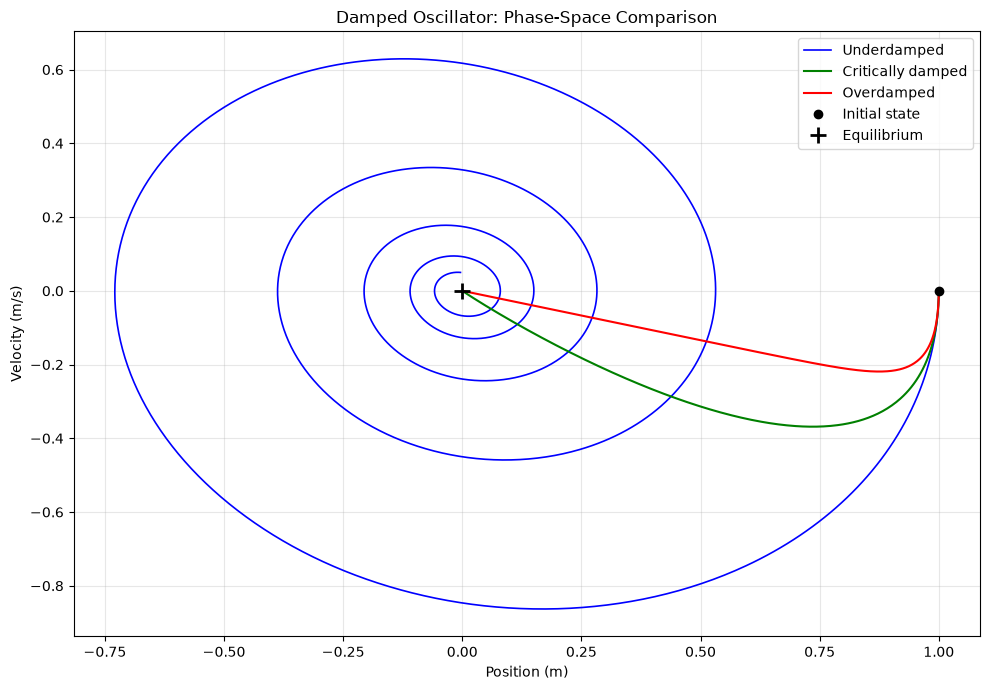

In [11]:
plt.figure(figsize=(10, 7))

plt.plot(
    x_under, v_under,
    color='blue',
    label='Underdamped',
    linewidth=1.2
)

plt.plot(
    x_critical, v_critical,
    color='green',
    label='Critically damped',
    linewidth=1.5
)

plt.plot(
    x_over, v_over,
    color='red',
    label='Overdamped',
    linewidth=1.5
)

# Shared initial state
plt.plot(
    x0, v0,
    marker='o',
    color='black',
    linestyle='None',
    label='Initial state'
)

# Equilibrium state
plt.plot(
    0.0, 0.0,
    marker='+',
    color='black',
    linestyle='None',
    markersize=12,
    markeredgewidth=2,
    label='Equilibrium'
)

plt.xlabel('Position (m)')
plt.ylabel('Velocity (m/s)')
plt.title('Damped Oscillator: Phase-Space Comparison')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Energy decay for the three damping regimes

I compare total mechanical energy for the underdamped, critically
damped, and overdamped cases. All three begin with the same energy
because their masses, spring constants, and initial conditions are
identical.

For the physical system, the rate of energy change is

$$\frac{dE}{dt}=-bv^2.$$

Energy loss therefore depends on both the damping coefficient and
the velocity. A larger damping coefficient does not necessarily
produce faster energy loss throughout the motion.

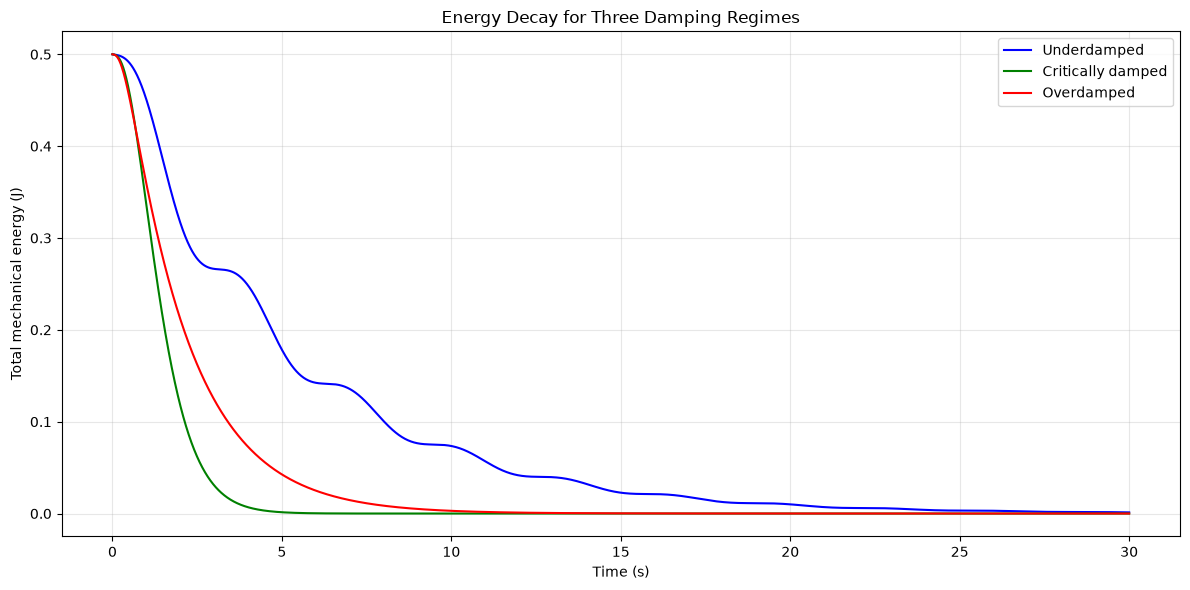

In [12]:
plt.figure(figsize=(12, 6))

plt.plot(
    t_under, E_under,
    color='blue',
    label='Underdamped',
    linewidth=1.5
)

plt.plot(
    t_critical, E_critical,
    color='green',
    label='Critically damped',
    linewidth=1.5
)

plt.plot(
    t_over, E_over,
    color='red',
    label='Overdamped',
    linewidth=1.5
)

plt.xlabel('Time (s)')
plt.ylabel('Total mechanical energy (J)')
plt.title('Energy Decay for Three Damping Regimes')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Interpretation

The underdamped oscillator continues crossing equilibrium with
decreasing amplitude, approximately following the theoretical decay
envelope, while its phase-space curve spirals inward. The critically
damped and overdamped cases approach the origin without spiraling;
for these initial conditions, the critical case settles sooner.
The energy plots show that all three lose mechanical energy over
time, but stronger damping does not always mean faster energy loss
because the loss rate also depends on velocity.

## Part C — Driven Oscillations and Resonance

I add a periodic external force to the damped oscillator. The equation
of motion becomes

$$a=-\frac{k}{m}x-\frac{b}{m}v
+\frac{F_0}{m}\cos(\omega_dt).$$

Here, F0 is the driving-force amplitude and omega_d is the driving
angular frequency. The natural angular frequency omega0 remains
determined by the mass and spring constant.

I start the mass at equilibrium and at rest. I will first examine
how the initial transient fades, leaving a steady-state oscillation
at the driving frequency.

In [13]:
def simulate_driven_sho(omega_d, F0=1.0, b=0.2,
                        dt=0.01, t_max=150.0):
    """Simulate a driven, damped oscillator using Euler-Cromer.

    Parameters:
        omega_d : driving angular frequency (rad/s)
        F0      : driving-force amplitude (N)
        b       : damping coefficient (kg/s)
        dt      : time step (s)
        t_max   : requested duration (s)

    Uses k and m defined above.
    Returns arrays of time, position, velocity, and energy.
    """

    # Start at equilibrium and at rest
    t = 0.0
    x = 0.0
    v = 0.0

    t_history = [t]
    x_history = [x]
    v_history = [v]
    E_history = [0.0]

    while t < t_max:
        # Forces evaluated at the current state and time
        force_spring = -k * x
        force_damping = -b * v
        force_driving = F0 * np.cos(omega_d * t)

        # Newton's second law
        a = (force_spring + force_damping + force_driving) / m

        # Euler-Cromer update
        v = v + a * dt
        x = x + v * dt
        t = t + dt

        # Mechanical energy at the updated state
        energy = 0.5 * k * x**2 + 0.5 * m * v**2

        t_history.append(t)
        x_history.append(x)
        v_history.append(v)
        E_history.append(energy)

    return (
        np.array(t_history),
        np.array(x_history),
        np.array(v_history),
        np.array(E_history)
    )

### Transient to steady state

I use a driving-force amplitude of 1.0 N and damping coefficient
b = 0.2 kg/s. The driving angular frequency equals the natural
angular frequency.

The transient decays on a timescale set by beta = b/(2m).
I mark t = 8/beta as a practical reference for when the transient
envelope has fallen to exp(-8), about 0.034% of its initial value.
There is no exact instant when the transient ends.

I also plot the predicted steady-state amplitude as a reference
for the late-time numerical oscillations.

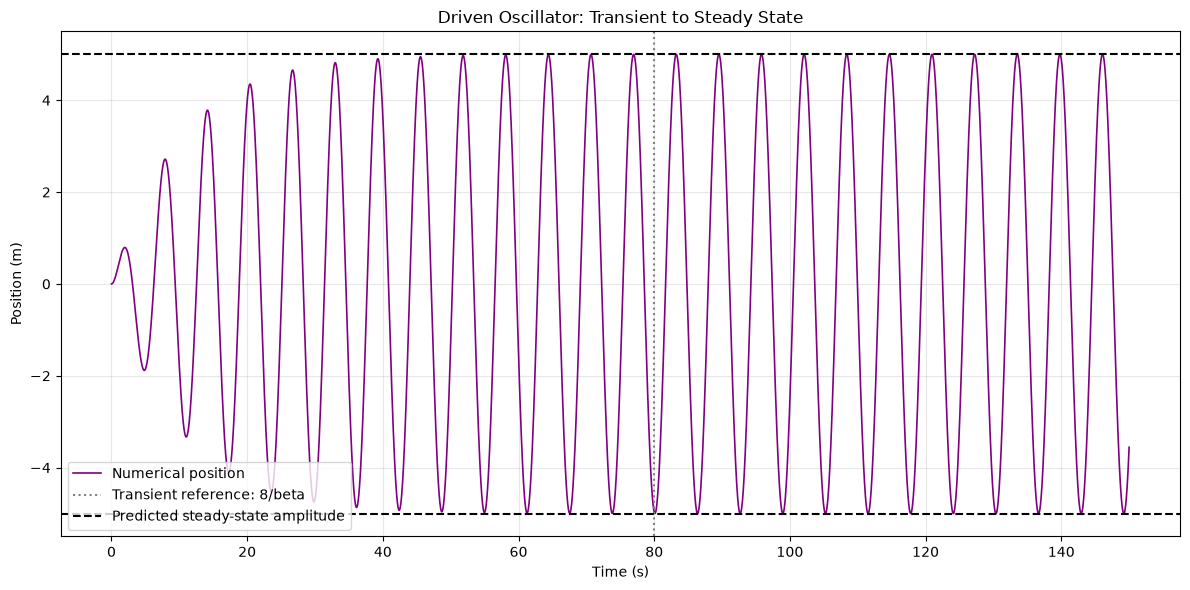

Driving angular frequency: 1.0000 rad/s
Transient reference time: 80.00 s
Predicted steady-state amplitude: 5.0000 m


In [14]:
# Driving and damping parameters
F0_driven = 1.0       # N
b_driven = 0.2        # kg/s
omega_d_test = omega0 # rad/s

# Run the simulation
t_driven, x_driven, v_driven, E_driven = simulate_driven_sho(
    omega_d=omega_d_test,
    F0=F0_driven,
    b=b_driven,
    dt=0.01,
    t_max=150.0
)

# Practical reference time for a small remaining transient
beta_driven = b_driven / (2 * m)
settling_time = 8 / beta_driven

# Analytical steady-state displacement amplitude (m)
A_steady = F0_driven / np.sqrt(
    (k - m * omega_d_test**2)**2
    + (b_driven * omega_d_test)**2
)

plt.figure(figsize=(12, 6))

plt.plot(
    t_driven, x_driven,
    color='purple',
    label='Numerical position',
    linewidth=1.2
)

plt.axvline(
    x=settling_time,
    color='gray',
    linestyle=':',
    label='Transient reference: 8/beta'
)

plt.axhline(
    y=A_steady,
    color='black',
    linestyle='--',
    label='Predicted steady-state amplitude'
)

plt.axhline(
    y=-A_steady,
    color='black',
    linestyle='--'
)

plt.xlabel('Time (s)')
plt.ylabel('Position (m)')
plt.title('Driven Oscillator: Transient to Steady State')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Driving angular frequency: {omega_d_test:.4f} rad/s")
print(f"Transient reference time: {settling_time:.2f} s")
print(f"Predicted steady-state amplitude: {A_steady:.4f} m")

### Building the resonance curve

I vary the driving angular frequency from 0.2 to 2.0 rad/s while
keeping the mass, spring constant, damping, and driving-force
amplitude fixed.

For each frequency, I run the simulation for 300 seconds and measure
the largest absolute displacement during the final 20% of the run.
This allows the transient to decay before measuring the amplitude.

I compare the numerical amplitudes with the analytical prediction:

$$A(\omega_d)=
\frac{F_0}
{\sqrt{(k-m\omega_d^2)^2+(b\omega_d)^2}}.$$

Agreement with this curve provides a check on the simulation.

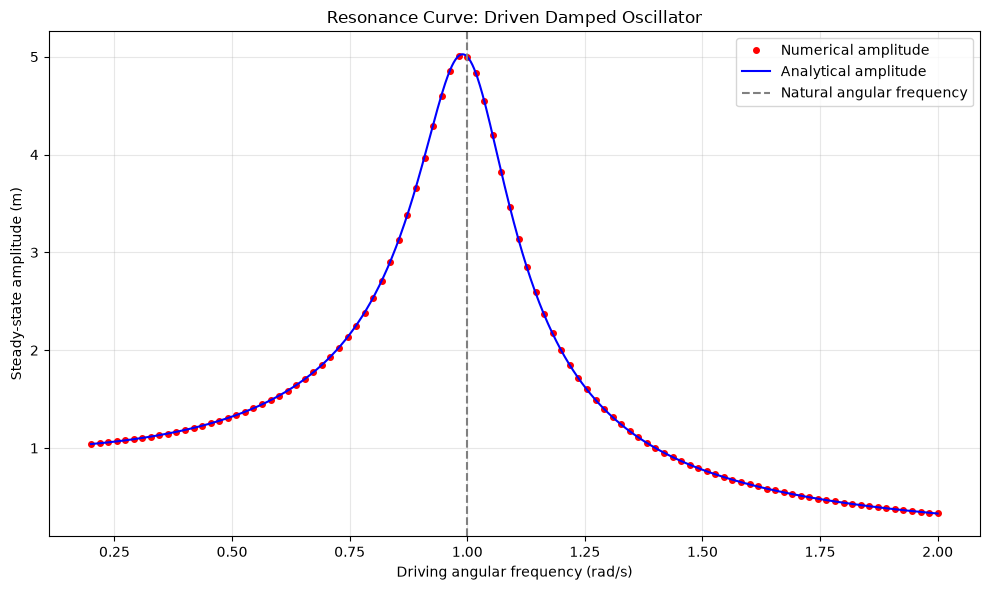

In [15]:
# Driving angular frequencies to test (rad/s)
omega_values = np.linspace(0.2, 2.0, 100)

# Store one measured amplitude per driving frequency
amplitudes = []

for omega_d in omega_values:
    t_run, x_run, v_run, E_run = simulate_driven_sho(
        omega_d=omega_d,
        F0=F0_driven,
        b=b_driven,
        dt=0.01,
        t_max=300.0
    )

    # Keep the final 20% of the position history
    tail_start = int(0.8 * len(x_run))
    x_tail = x_run[tail_start:]

    # Measure the steady-state amplitude
    amplitude = np.max(np.abs(x_tail))
    amplitudes.append(amplitude)

amplitudes = np.array(amplitudes)

# Analytical curve on a finer frequency grid
omega_reference = np.linspace(0.2, 2.0, 1000)

A_reference = F0_driven / np.sqrt(
    (k - m * omega_reference**2)**2
    + (b_driven * omega_reference)**2
)

plt.figure(figsize=(10, 6))

plt.plot(
    omega_values, amplitudes,
    color='red',
    marker='o',
    linestyle='None',
    markersize=4,
    label='Numerical amplitude'
)

plt.plot(
    omega_reference, A_reference,
    color='blue',
    linewidth=1.5,
    label='Analytical amplitude'
)

plt.axvline(
    x=omega0,
    color='gray',
    linestyle='--',
    label='Natural angular frequency'
)

plt.xlabel('Driving angular frequency (rad/s)')
plt.ylabel('Steady-state amplitude (m)')
plt.title('Resonance Curve: Driven Damped Oscillator')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Locating the resonance peak

I identify the largest measured amplitude and its corresponding
driving frequency.

For the analytical displacement-amplitude curve, the peak occurs at

$$\omega_{\mathrm{peak}}
=\sqrt{\omega_0^2-2\beta^2},
\qquad \beta=\frac{b}{2m},$$

provided beta is less than omega0 divided by the square root of 2.
That condition holds for this simulation.

The numerical peak is selected from a finite frequency grid, so its
location is limited by the spacing between tested frequencies as
well as numerical integration error.

In [16]:
# Index of the largest measured amplitude
peak_index = np.argmax(amplitudes)

# Retrieve the frequency and amplitude at that index
omega_peak_numerical = omega_values[peak_index]
A_peak_numerical = amplitudes[peak_index]

# Analytical peak frequency
omega_peak_theory = np.sqrt(
    omega0**2 - 2 * beta_driven**2
)

# Spacing between tested frequencies
frequency_spacing = omega_values[1] - omega_values[0]

print(f"Natural angular frequency: {omega0:.6f} rad/s")
print(f"Numerical peak frequency: {omega_peak_numerical:.6f} rad/s")
print(f"Analytical peak frequency: {omega_peak_theory:.6f} rad/s")
print(f"Numerical peak amplitude: {A_peak_numerical:.6f} m")
print(f"Frequency-grid spacing: {frequency_spacing:.6f} rad/s")

Natural angular frequency: 1.000000 rad/s
Numerical peak frequency: 0.981818 rad/s
Analytical peak frequency: 0.989949 rad/s
Numerical peak amplitude: 5.004582 m
Frequency-grid spacing: 0.018182 rad/s


### Effect of damping on resonance

I repeat the frequency sweep with damping coefficients of 0.1, 0.2,
and 0.5 kg/s, keeping the other physical parameters unchanged.
These are the three damping values suggested in the assignment.

For each simulation, I measure the amplitude during the final 20%
of a 300-second run. This also gives the transient time to decay
for the weakest damping case.

I compare the height, width, and location of the resonance peaks.

b = 0.1 kg/s: sampled peak at 1.000000 rad/s, amplitude = 10.000030 m
b = 0.2 kg/s: sampled peak at 0.981818 rad/s, amplitude = 5.004582 m
b = 0.5 kg/s: sampled peak at 0.945455 rad/s, amplitude = 2.061940 m


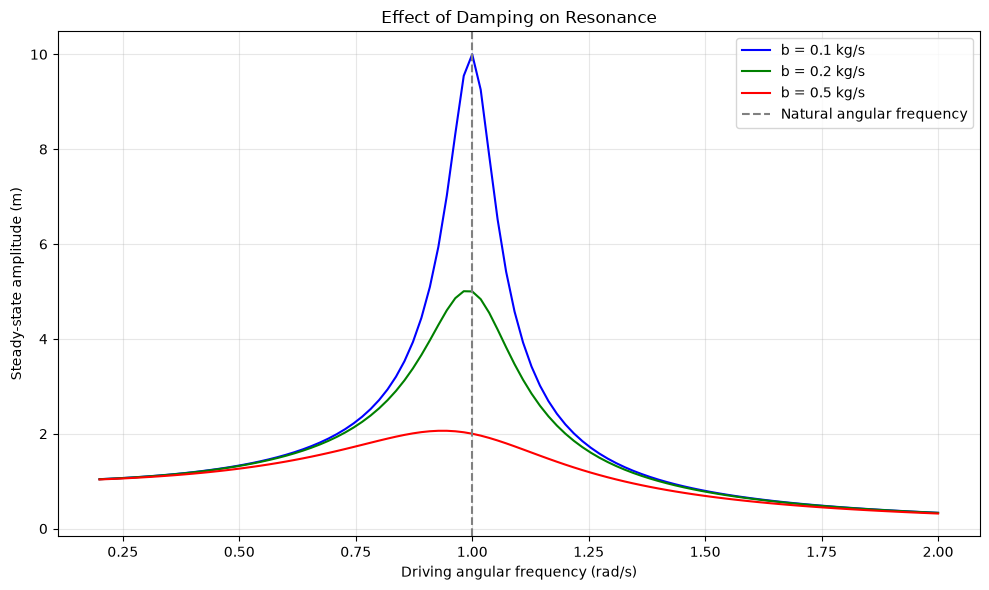

In [17]:
# Damping coefficients suggested in the assignment (kg/s)
damping_values = [0.1, 0.2, 0.5]
colors = ['blue', 'green', 'red']

plt.figure(figsize=(10, 6))

for b_value, color in zip(damping_values, colors):
    # Start a new amplitude list for this damping coefficient
    amplitudes_for_b = []

    for omega_d in omega_values:
        t_run, x_run, v_run, E_run = simulate_driven_sho(
            omega_d=omega_d,
            F0=F0_driven,
            b=b_value,
            dt=0.01,
            t_max=300.0
        )

        # Measure amplitude after the transient has decayed
        tail_start = int(0.8 * len(x_run))
        amplitude = np.max(np.abs(x_run[tail_start:]))
        amplitudes_for_b.append(amplitude)

    amplitudes_for_b = np.array(amplitudes_for_b)

    # Plot this damping coefficient's resonance curve
    plt.plot(
        omega_values, amplitudes_for_b,
        color=color,
        label=f'b = {b_value} kg/s',
        linewidth=1.5
    )

    # Report the largest sampled amplitude and its frequency
    peak_index_b = np.argmax(amplitudes_for_b)

    print(
        f"b = {b_value:.1f} kg/s: "
        f"sampled peak at {omega_values[peak_index_b]:.6f} rad/s, "
        f"amplitude = {amplitudes_for_b[peak_index_b]:.6f} m"
    )

plt.axvline(
    x=omega0,
    color='gray',
    linestyle='--',
    label='Natural angular frequency'
)

plt.xlabel('Driving angular frequency (rad/s)')
plt.ylabel('Steady-state amplitude (m)')
plt.title('Effect of Damping on Resonance')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Interpretation

The driven oscillator initially builds in amplitude before settling into approximately steady oscillations as the transient decays. With b = 0.2 kg/s, the largest sampled amplitude was about 5.005 m at a driving frequency of 0.981818 rad/s, close to the analytical peak of 0.989949 rad/s; the frequency-grid spacing limits how precisely the sweep locates that peak. The response peaks near the natural frequency because the driving force transfers energy efficiently to the oscillator, with damping limiting the steady-state amplitude. Reducing damping produces a taller, narrower peak, while increasing damping lowers and broadens it and shifts it toward a lower driving frequency.


## Bonus — The Nonlinear Pendulum

I simulate a pendulum using the full equation of motion,

$$\ddot{\theta}=-\frac{g}{L}\sin\theta.$$

For small angles, replacing sin(theta) with theta gives the
small-angle period

$$T_{\mathrm{small}}=2\pi\sqrt{\frac{L}{g}}.$$

I keep the full sine function and release the pendulum from rest
at different initial angles. I will measure the numerical period
and compare it with the small-angle prediction.

In [18]:
def simulate_pendulum(theta0_deg, dt=0.001, n_periods=10):
    """Simulate a nonlinear pendulum using Euler-Cromer.

    Parameters:
        theta0_deg : initial angular displacement (degrees)
        dt         : time step (s)
        n_periods  : duration measured in small-angle periods

    Returns:
        Time (s), angle (rad), and angular velocity (rad/s) arrays.
    """

    # Pendulum parameters
    g_pendulum = 9.81  # m/s²
    L = 1.0           # m

    # Small-angle period sets the simulation duration
    T_small = 2 * np.pi * np.sqrt(L / g_pendulum)
    t_max = n_periods * T_small

    # Release from rest at the requested angle
    theta = np.radians(theta0_deg)
    omega = 0.0
    t = 0.0

    t_history = [t]
    theta_history = [theta]
    omega_history = [omega]

    while t < t_max:
        # Full nonlinear angular acceleration
        alpha = -(g_pendulum / L) * np.sin(theta)

        # Euler-Cromer: angular velocity first, then angle
        omega = omega + alpha * dt
        theta = theta + omega * dt
        t = t + dt

        t_history.append(t)
        theta_history.append(theta)
        omega_history.append(omega)

    return (
        np.array(t_history),
        np.array(theta_history),
        np.array(omega_history)
    )

### Measuring the pendulum period

I identify crossings of equilibrium where the angle changes from
positive to negative. Consecutive crossings in this same direction
are separated by one full period.

The crossing usually falls between stored time points, so I use
linear interpolation to estimate its time. I then average the
intervals between crossings to obtain the measured period.

In [19]:
def measure_period(t, theta):
    """Estimate the period from positive-to-negative zero crossings.

    Parameters:
        t     : array of times (s)
        theta : array of angular displacements (rad)

    Returns:
        Mean interval between successive downward crossings (s).
    """

    crossing_times = []

    # Compare each angle with the preceding angle
    for i in range(1, len(theta)):
        if theta[i - 1] > 0 and theta[i] <= 0:

            # Fraction of the step needed to reach theta = 0
            fraction = theta[i - 1] / (
                theta[i - 1] - theta[i]
            )

            # Interpolated crossing time
            crossing_time = t[i - 1] + fraction * (
                t[i] - t[i - 1]
            )

            crossing_times.append(crossing_time)

    # At least two crossings are needed to measure one period
    if len(crossing_times) < 2:
        raise ValueError(
            "Not enough crossings to measure a period. "
            "Run the simulation for longer."
        )

    # Time intervals between successive crossings
    periods = np.diff(crossing_times)

    return np.mean(periods)

### Periods at small and large amplitudes

I simulate releases from rest at 5, 30, 90, and 150 degrees.
For each starting angle, I measure the period and calculate its
percentage increase relative to the small-angle prediction.

The 5-degree case checks whether the simulation agrees closely
with the small-angle limit. The larger angles test how the period
changes when that approximation becomes less accurate.

In [20]:
# Parameters matching the pendulum simulator
g_pendulum = 9.81  # m/s²
L_pendulum = 1.0   # m

T_small = 2 * np.pi * np.sqrt(L_pendulum / g_pendulum)

# Starting angles requested for the comparison
starting_angles = [5.0, 30.0, 90.0, 150.0]

measured_periods = []
period_increases = []

for angle in starting_angles:
    t_pend, theta_pend, omega_pend = simulate_pendulum(
        theta0_deg=angle,
        dt=0.001,
        n_periods=10
    )

    period = measure_period(t_pend, theta_pend)

    percentage_increase = (
        (period - T_small) / T_small
    ) * 100

    measured_periods.append(period)
    period_increases.append(percentage_increase)

# Convert results to arrays for later use
measured_periods = np.array(measured_periods)
period_increases = np.array(period_increases)

print(f"Small-angle predicted period: {T_small:.6f} s")
print()
print(f"{'Angle (deg)':>12} {'Period (s)':>14} {'Increase (%)':>16}")

for i in range(len(starting_angles)):
    print(
        f"{starting_angles[i]:12.1f} "
        f"{measured_periods[i]:14.6f} "
        f"{period_increases[i]:16.4f}"
    )

Small-angle predicted period: 2.006067 s

 Angle (deg)     Period (s)     Increase (%)
         5.0       2.007021           0.0476
        30.0       2.040989           1.7408
        90.0       2.367842          18.0341
       150.0       3.535099          76.2204


### Period versus starting amplitude

I vary the initial angle from 5 to 170 degrees in 1-degree steps,
releasing the pendulum from rest each time. I measure the period
using successive downward crossings of equilibrium.

I use a 3% increase relative to the small-angle period as a specific
meaning of "a few percent." The first sampled angle exceeding this
threshold estimates where the small-angle prediction becomes
inaccurate by that criterion.

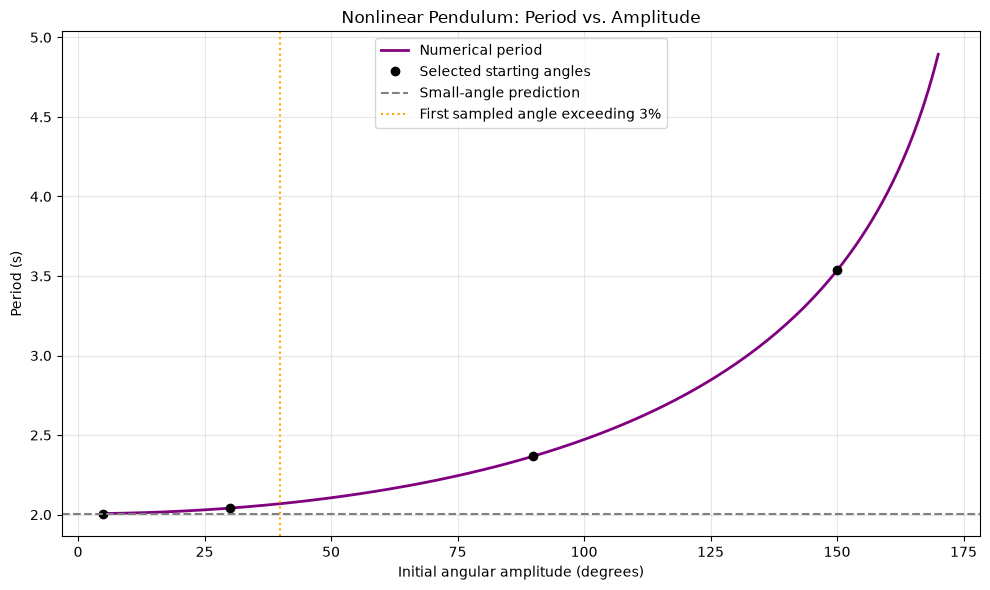

At 39 degrees: 2.9750% increase
At 40 degrees: 3.1340% increase


In [21]:
# Starting angles from 5 through 170 degrees
amplitude_angles = np.arange(5.0, 171.0, 1.0)

periods_sweep = []

for angle in amplitude_angles:
    t_run, theta_run, omega_run = simulate_pendulum(
        theta0_deg=angle,
        dt=0.001,
        n_periods=10
    )

    period = measure_period(t_run, theta_run)
    periods_sweep.append(period)

periods_sweep = np.array(periods_sweep)

# Percentage increase relative to the small-angle period
increases_sweep = (
    (periods_sweep - T_small) / T_small
) * 100

# Locate the first sampled angle exceeding 3%
threshold_percent = 3.0
above_threshold = np.where(
    increases_sweep > threshold_percent
)[0]

first_index = above_threshold[0]
threshold_angle = amplitude_angles[first_index]

# Plot the numerical periods
plt.figure(figsize=(10, 6))

plt.plot(
    amplitude_angles, periods_sweep,
    color='purple',
    label='Numerical period',
    linewidth=2
)

# Highlight the four cases already studied
plt.plot(
    starting_angles, measured_periods,
    color='black',
    marker='o',
    linestyle='None',
    label='Selected starting angles'
)

plt.axhline(
    y=T_small,
    color='gray',
    linestyle='--',
    label='Small-angle prediction'
)

plt.axvline(
    x=threshold_angle,
    color='orange',
    linestyle=':',
    label='First sampled angle exceeding 3%'
)

plt.xlabel('Initial angular amplitude (degrees)')
plt.ylabel('Period (s)')
plt.title('Nonlinear Pendulum: Period vs. Amplitude')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Report the samples on either side of the threshold
print(
    f"At {amplitude_angles[first_index - 1]:.0f} degrees: "
    f"{increases_sweep[first_index - 1]:.4f}% increase"
)

print(
    f"At {threshold_angle:.0f} degrees: "
    f"{increases_sweep[first_index]:.4f}% increase"
)

### Checking the measured periods against a smaller time step

I repeat the four selected starting-angle simulations with the time
step reduced from 0.001 s to 0.0005 s. I compare the measured periods
between these runs.

A small change under this refinement supports the conclusion that
the much larger period increases at large amplitudes come from the
nonlinear physics rather than the chosen time step. This comparison
checks sensitivity to step size; it does not establish an exact
numerical error.

In [22]:
periods_fine = []

for angle in starting_angles:
    t_fine, theta_fine, omega_fine = simulate_pendulum(
        theta0_deg=angle,
        dt=0.0005,
        n_periods=10
    )

    periods_fine.append(measure_period(t_fine, theta_fine))

periods_fine = np.array(periods_fine)

# Differences between the two numerical period estimates
period_changes = np.abs(periods_fine - measured_periods)

relative_changes = (
    period_changes / np.abs(periods_fine)
) * 100

print(
    f"{'Angle (deg)':>12} "
    f"{'Original T (s)':>16} "
    f"{'Refined T (s)':>16} "
    f"{'Change (%)':>14}"
)

for i in range(len(starting_angles)):
    print(
        f"{starting_angles[i]:12.1f} "
        f"{measured_periods[i]:16.8f} "
        f"{periods_fine[i]:16.8f} "
        f"{relative_changes[i]:14.6f}"
    )

 Angle (deg)   Original T (s)    Refined T (s)     Change (%)
         5.0       2.00702110       2.00702171       0.000031
        30.0       2.04098917       2.04098971       0.000027
        90.0       2.36784195       2.36784195       0.000000
       150.0       3.53509944       3.53509850       0.000027


### Interpretation

The measured period increases with starting amplitude: it is only 0.0476% longer than the small-angle prediction at 5°, but 18.0341% longer at 90° and 76.2204% longer at 150°. Using 3% as the cutoff for “a few percent,” the threshold lies between 39° and 40°, where the measured increases are 2.9750% and 3.1340%, respectively. Halving the time step changes the measured periods by at most about 0.000031%, supporting the conclusion that the longer periods at large amplitudes result from the nonlinear physics rather than time-step error.
